# Part 1: Acne Detection on ACNE04

This notebook trains and compares **three object detectors** on the ACNE04 dataset:

| Model | Family | Anchors |
|---|---|---|
| **YOLOv8** | One-stage CNN | Anchor-free |
| **Faster R-CNN + ResNet50-FPN** | Two-stage CNN | Anchor-based |
| **RT-DETR** (DINO family) | One-stage Transformer | Anchor-free queries |

Run end-to-end on Colab (T4 GPU) in ~3 hours.


## 0. Setup

Link: https://github.com/nprakash1/acne_yang_project/tree/main/part1_detection

In [1]:
# Auto-detect how the project got into this Colab runtime.
# Supports three workflows -- you don't have to edit anything:
#   (1) git clone   - set GITHUB_URL below to a public repo URL
#   (2) zip upload  - drag acne_yang_project.zip into Colab's file pane
#   (3) Drive copy  - put the unzipped folder anywhere in your Drive
import os, glob, subprocess

GITHUB_URL = 'https://github.com/nprakash1/acne_yang_project.git'
PROJECT_DIR = 'acne_yang_project'

def _is_project_root(p):
    return os.path.isdir(os.path.join(p, 'part1_detection')) and \
           os.path.isfile(os.path.join(p, 'requirements.txt'))

# Already at project root?
if _is_project_root('.'):
    print('[setup] already at project root')
elif os.path.isdir(PROJECT_DIR) and _is_project_root(PROJECT_DIR):
    %cd $PROJECT_DIR
    print(f'[setup] cd into ./{PROJECT_DIR}')
else:
    zips = glob.glob('/content/*.zip') + glob.glob('./*.zip')
    drive_hits = glob.glob('/content/drive/MyDrive/**/part1_detection', recursive=True)
    if zips:
        z = zips[0]
        print(f'[setup] unzipping {z}')
        subprocess.check_call(['unzip', '-q', '-o', z, '-d', '/content/_extracted'])
        roots = [r for r, _, _ in os.walk('/content/_extracted') if _is_project_root(r)]
        assert roots, 'zip did not contain a project root (part1_detection/ + requirements.txt)'
        %cd $roots[0]
    elif drive_hits:
        root = os.path.dirname(drive_hits[0])
        print(f'[setup] using project from Drive: {root}')
        %cd $root
    elif GITHUB_URL:
        print(f'[setup] cloning {GITHUB_URL}')
        subprocess.check_call(['git', 'clone', GITHUB_URL])
        %cd $PROJECT_DIR
    else:
        raise RuntimeError(
            'No project source found. Either:\n'
            ' - set GITHUB_URL above to your repo, or\n'
            ' - drag acne_yang_project.zip into the Colab file pane and re-run, or\n'
            ' - mount Drive (next cell) with the project folder inside MyDrive.'
        )

print('[setup] cwd =', os.getcwd())
!pip install -q -r requirements.txt
print('[setup] dependencies installed')

[setup] cloning https://github.com/nprakash1/acne_yang_project.git
/content/acne_yang_project
[setup] cwd = /content/acne_yang_project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 51.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.6 MB/s eta 0:00:00
[setup] dependencies installed


In [2]:

# Mount drive (optional, for persisting weights)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

Mounted at /content/drive


## 1. Download ACNE04

We pull the dataset from Roboflow Universe in **both YOLOv8 and COCO formats** so the same images back all three models. You need a free Roboflow API key from https://app.roboflow.com/settings/api.

In [3]:
import os
os.environ['ROBOFLOW_API_KEY'] = 'c1orEQIdQdZYPwUiFe2I'

from part1_detection.data import download_acne04, build_yaml
yolo_root = download_acne04(out_dir='data/acne04', fmt='yolov8')
coco_root = download_acne04(out_dir='data/acne04', fmt='coco')
yaml_path = build_yaml(yolo_root, 'data/acne04.yaml')
print('YOLO root:', yolo_root)
print('COCO root:', coco_root)
print('YAML:', yaml_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/yolov8 in yolov8:: 100%|██████████| 6808/6808 [00:00<00:00, 9069.98it/s]

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/acne_yang_project/data/acne04/coco in coco:: 100%|██████████| 3406/3406 [00:00<00:00, 7036.25it/s]


YOLO root: /content/acne_yang_project/data/acne04/yolov8
COCO root: /content/acne_yang_project/data/acne04/coco
YAML: /content/acne_yang_project/data/acne04.yaml


### Fix YOLO class labels (critical)

Roboflow's ACNE04 YOLO export uses class ids `0/1/2/3` for the four severity levels (`levle0..levle3`), but our pipeline treats acne as a **single class**. Ultralytics silently drops every label whose class id exceeds `nc-1`, so without this remap ~75% of training data is thrown away as 'corrupt'. Safe to re-run.

In [ ]:
from part1_detection.fix_yolo_labels import remap_labels_to_single_class
remap_labels_to_single_class(str(yolo_root))


## 1.5 Inspect GT bounding boxes

ACNE04 lesions are *small* (typically 5-30 px). Before training we measure the actual size distribution to:

1. **Sanity-check** the dataset annotations.
2. Choose **data-driven anchor sizes** for Faster R-CNN (torchvision defaults target COCO objects, ~10x larger).
3. Confirm an `imgsz` for YOLO / RT-DETR that makes the median lesion comfortably visible to the FPN.

Outputs land in `outputs/eda/`.

In [ ]:
from part1_detection.analyze_gt import analyze
from IPython.display import Image as IPyImage, display

gt_stats = analyze(
    coco_path=f'{coco_root}/train/_annotations.coco.json',
    out_dir='outputs/eda',
)

for fn in ('gt_size_distribution.png',
           'gt_aspect_distribution.png',
           'gt_per_image.png'):
    display(IPyImage(filename=f'outputs/eda/{fn}'))


### Apply data-driven settings to the detectors

The cell below reads `gt_stats` and:

* Builds `REC_ANCHOR_SIZES` / `REC_ASPECT_RATIOS` for Faster R-CNN.
* Picks `IMGSZ` so the **median lesion is ~16 px after resize** (FPN P3 stride-8 -- the sweet spot for small-object recall). Rounded to a multiple of 32 and clipped to [640, 1536].
* Monkey-patches `train_faster_rcnn.build_model` so the training cell below picks up the new anchors with no code edit.

In [ ]:
# Data-driven anchor sizes for Faster R-CNN ----------------------
REC_ANCHOR_SIZES  = tuple(tuple(t) for t in gt_stats['recommended_anchor_sizes'])
REC_ASPECT_RATIOS = tuple(gt_stats['recommended_aspect_ratios'])
print('anchor_sizes  :', REC_ANCHOR_SIZES)
print('aspect_ratios :', REC_ASPECT_RATIOS)

# Data-driven imgsz for YOLO / RT-DETR ---------------------------
# Target: median lesion == 16 px after resize.
med_lesion = gt_stats['box_size_px']['p50']
src_w      = gt_stats['image_size_median'][0]
raw_imgsz  = src_w * 16.0 / max(med_lesion, 1.0)
IMGSZ      = int(min(1536, max(640, round(raw_imgsz / 32) * 32)))
print(f'median lesion={med_lesion:.1f} px in {src_w:.0f}-px image '
      f'-> imgsz={IMGSZ}')

# Patch build_model() to use the new anchors --------------------
import part1_detection.train_faster_rcnn as _frcnn_mod
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead

_orig_build = _frcnn_mod.build_model

def _build_data_driven(num_classes=2, small_anchors=True):
    model = _orig_build(num_classes=num_classes, small_anchors=False)
    model.rpn.anchor_generator = AnchorGenerator(
        sizes=REC_ANCHOR_SIZES,
        aspect_ratios=(REC_ASPECT_RATIOS,) * len(REC_ANCHOR_SIZES),
    )
    in_ch  = model.backbone.out_channels
    n_anch = model.rpn.anchor_generator.num_anchors_per_location()[0]
    model.rpn.head = RPNHead(in_ch, n_anch)
    return model

_frcnn_mod.build_model = _build_data_driven
print('[patched] train_faster_rcnn.build_model -> data-driven anchors')


## 2. Train YOLOv8

In [4]:
from part1_detection.train_ultralytics import train_yolo
# Use the data-driven imgsz so the median lesion is ~16 px to the model.
yolo_results = train_yolo(
    data=str(yaml_path), epochs=150, imgsz=IMGSZ, batch=12,
)


Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

## 3. Train Faster R-CNN (ResNet50-FPN)

In [5]:
from part1_detection.train_faster_rcnn import train as train_frcnn
# longer schedule + smaller LR to match the bigger min/max image size and tighter anchors
frcnn_model = train_frcnn(coco_root=str(coco_root), epochs=40, batch_size=2, lr=2e-3)

train images: 2973  |  val images: 283
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 225MB/s]


  epoch 1 step 0/1487 loss 1.2713 (1.2713 avg)
  epoch 1 step 20/1487 loss 0.9536 (0.7835 avg)
  epoch 1 step 40/1487 loss 0.1265 (0.6395 avg)
  epoch 1 step 60/1487 loss 0.8564 (0.5556 avg)
  epoch 1 step 80/1487 loss 0.1307 (0.4888 avg)
  epoch 1 step 100/1487 loss 0.0542 (0.4447 avg)
  epoch 1 step 120/1487 loss 0.3579 (0.4157 avg)
  epoch 1 step 140/1487 loss 0.2505 (0.3894 avg)
  epoch 1 step 160/1487 loss 0.5720 (0.3919 avg)
  epoch 1 step 180/1487 loss 0.2628 (0.3788 avg)
  epoch 1 step 200/1487 loss 0.0737 (0.3682 avg)
  epoch 1 step 220/1487 loss 0.4476 (0.3580 avg)
  epoch 1 step 240/1487 loss 1.0553 (0.3656 avg)
  epoch 1 step 260/1487 loss 0.1339 (0.3645 avg)
  epoch 1 step 280/1487 loss 0.4090 (0.3697 avg)
  epoch 1 step 300/1487 loss 0.0589 (0.3620 avg)
  epoch 1 step 320/1487 loss 0.5039 (0.3595 avg)
  epoch 1 step 340/1487 loss 0.1794 (0.3527 avg)
  epoch 1 step 360/1487 loss 0.1274 (0.3495 avg)
  epoch 1 step 380/1487 loss 0.5885 (0.3469 avg)
  epoch 1 step 400/1487 lo

## 4. Train RT-DETR (DINO family)

In [6]:
from part1_detection.train_ultralytics import train_rtdetr
# RT-DETR benefits equally from the larger, data-driven input.
rtdetr_results = train_rtdetr(
    data=str(yaml_path), epochs=120, imgsz=IMGSZ, batch=6,
)


Ultralytics 8.4.49 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/acne_yang_project/data/acne04.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=acne, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      1/120      10.7G      1.771     0.3235     0.5848         48       1024: 100% ━━━━━━━━━━━━ 53/53 1.7it/s 32.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.2s/it 4.3s
                   all         22       1185      0.191      0.143     0.0612     0.0116

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/120      11.5G      1.507     0.3076     0.3993        345       1024: 0% ──────────── 0/53  0.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


      2/120      11.5G      1.241     0.3846      0.274         52       1024: 100% ━━━━━━━━━━━━ 53/53 2.7it/s 20.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 6.9it/s 0.3s
                   all         22       1185      0.286      0.278      0.163     0.0347

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/120      11.5G      1.103     0.4437     0.2449        310       1024: 0% ──────────── 0/53  0.4s

...

     45/120      11.5G        nan        nan        nan         52       1024: 100% ━━━━━━━━━━━━ 53/53 2.8it/s 19.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.7it/s 0.2s
                   all         22       1185          0          0          0          0
WARNING ⚠️ Skipping checkpoint save at epoch 44: EMA contains NaN/Inf

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     46/120      11.5G        nan        nan        nan        348       1024: 0% ──────────── 0/53  0.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     46/120      11.5G        nan        nan        nan         22       1024: 100% ━━━━━━━━━━━━ 53/53 2.8it/s 19.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.4it/s 0.2s
                   all         22       1185          0          0          0          0
WARNING ⚠️ Skipping checkpoint save at epoch 45: EMA contains NaN/Inf

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     47/120      11.5G     0.9683     0.4539     0.1848        302       1024: 0% ──────────── 0/53  0.4s

grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)


     47/120      11.5G        nan        nan        nan         54       1024: 100% ━━━━━━━━━━━━ 53/53 2.8it/s 19.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 8.6it/s 0.2s
                   all         22       1185          0          0          0          0
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 17, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.
WARNING ⚠️ Skipping checkpoint save at epoch 46: EMA contains NaN/Inf

47 epochs completed in 0.267 hours.
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/last.pt, 66.3MB
Optimizer stripped from /content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt, 66.3MB

Validating /content/acne_yang_project/runs/detect/outputs/rtdetr/acne

## 5. Unified Evaluation (mAP / P / R / IoU)

All three models scored with the **same pycocotools COCOeval** for an apples-to-apples comparison.

In [7]:
from part1_detection.evaluate import evaluate_model
import pandas as pd

metrics = {}
metrics['YOLOv8'] = evaluate_model('yolo', '/content/acne_yang_project/runs/detect/outputs/yolov8/acne/weights/best.pt', str(coco_root))
metrics['Faster R-CNN'] = evaluate_model('frcnn', 'outputs/faster_rcnn/best.pth', str(coco_root))
metrics['RT-DETR']     = evaluate_model('rtdetr', '/content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt', str(coco_root))

df = pd.DataFrame(metrics).T[['mAP@0.5', 'mAP@0.5:0.95', 'precision@0.5', 'recall@0.5', 'mean_iou']]
df

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.46s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=2.91s).
Accumulating evaluation results...
DONE (t=0.09s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.035
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.159
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.032
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.044
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | max

,mAP@0.5,mAP@0.5:0.95,precision@0.5,recall@0.5,mean_iou
YOLOv8,0.159468,0.035112,0.377119,0.102476,0.617207
Faster R-CNN,0.206075,0.045638,0.257820,0.450777,0.624569
RT-DETR,0.190510,0.040397,0.154051,0.433506,0.624798


## 6. Side-by-side bbox visualizations

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
saved outputs/viz/predictions_test.png


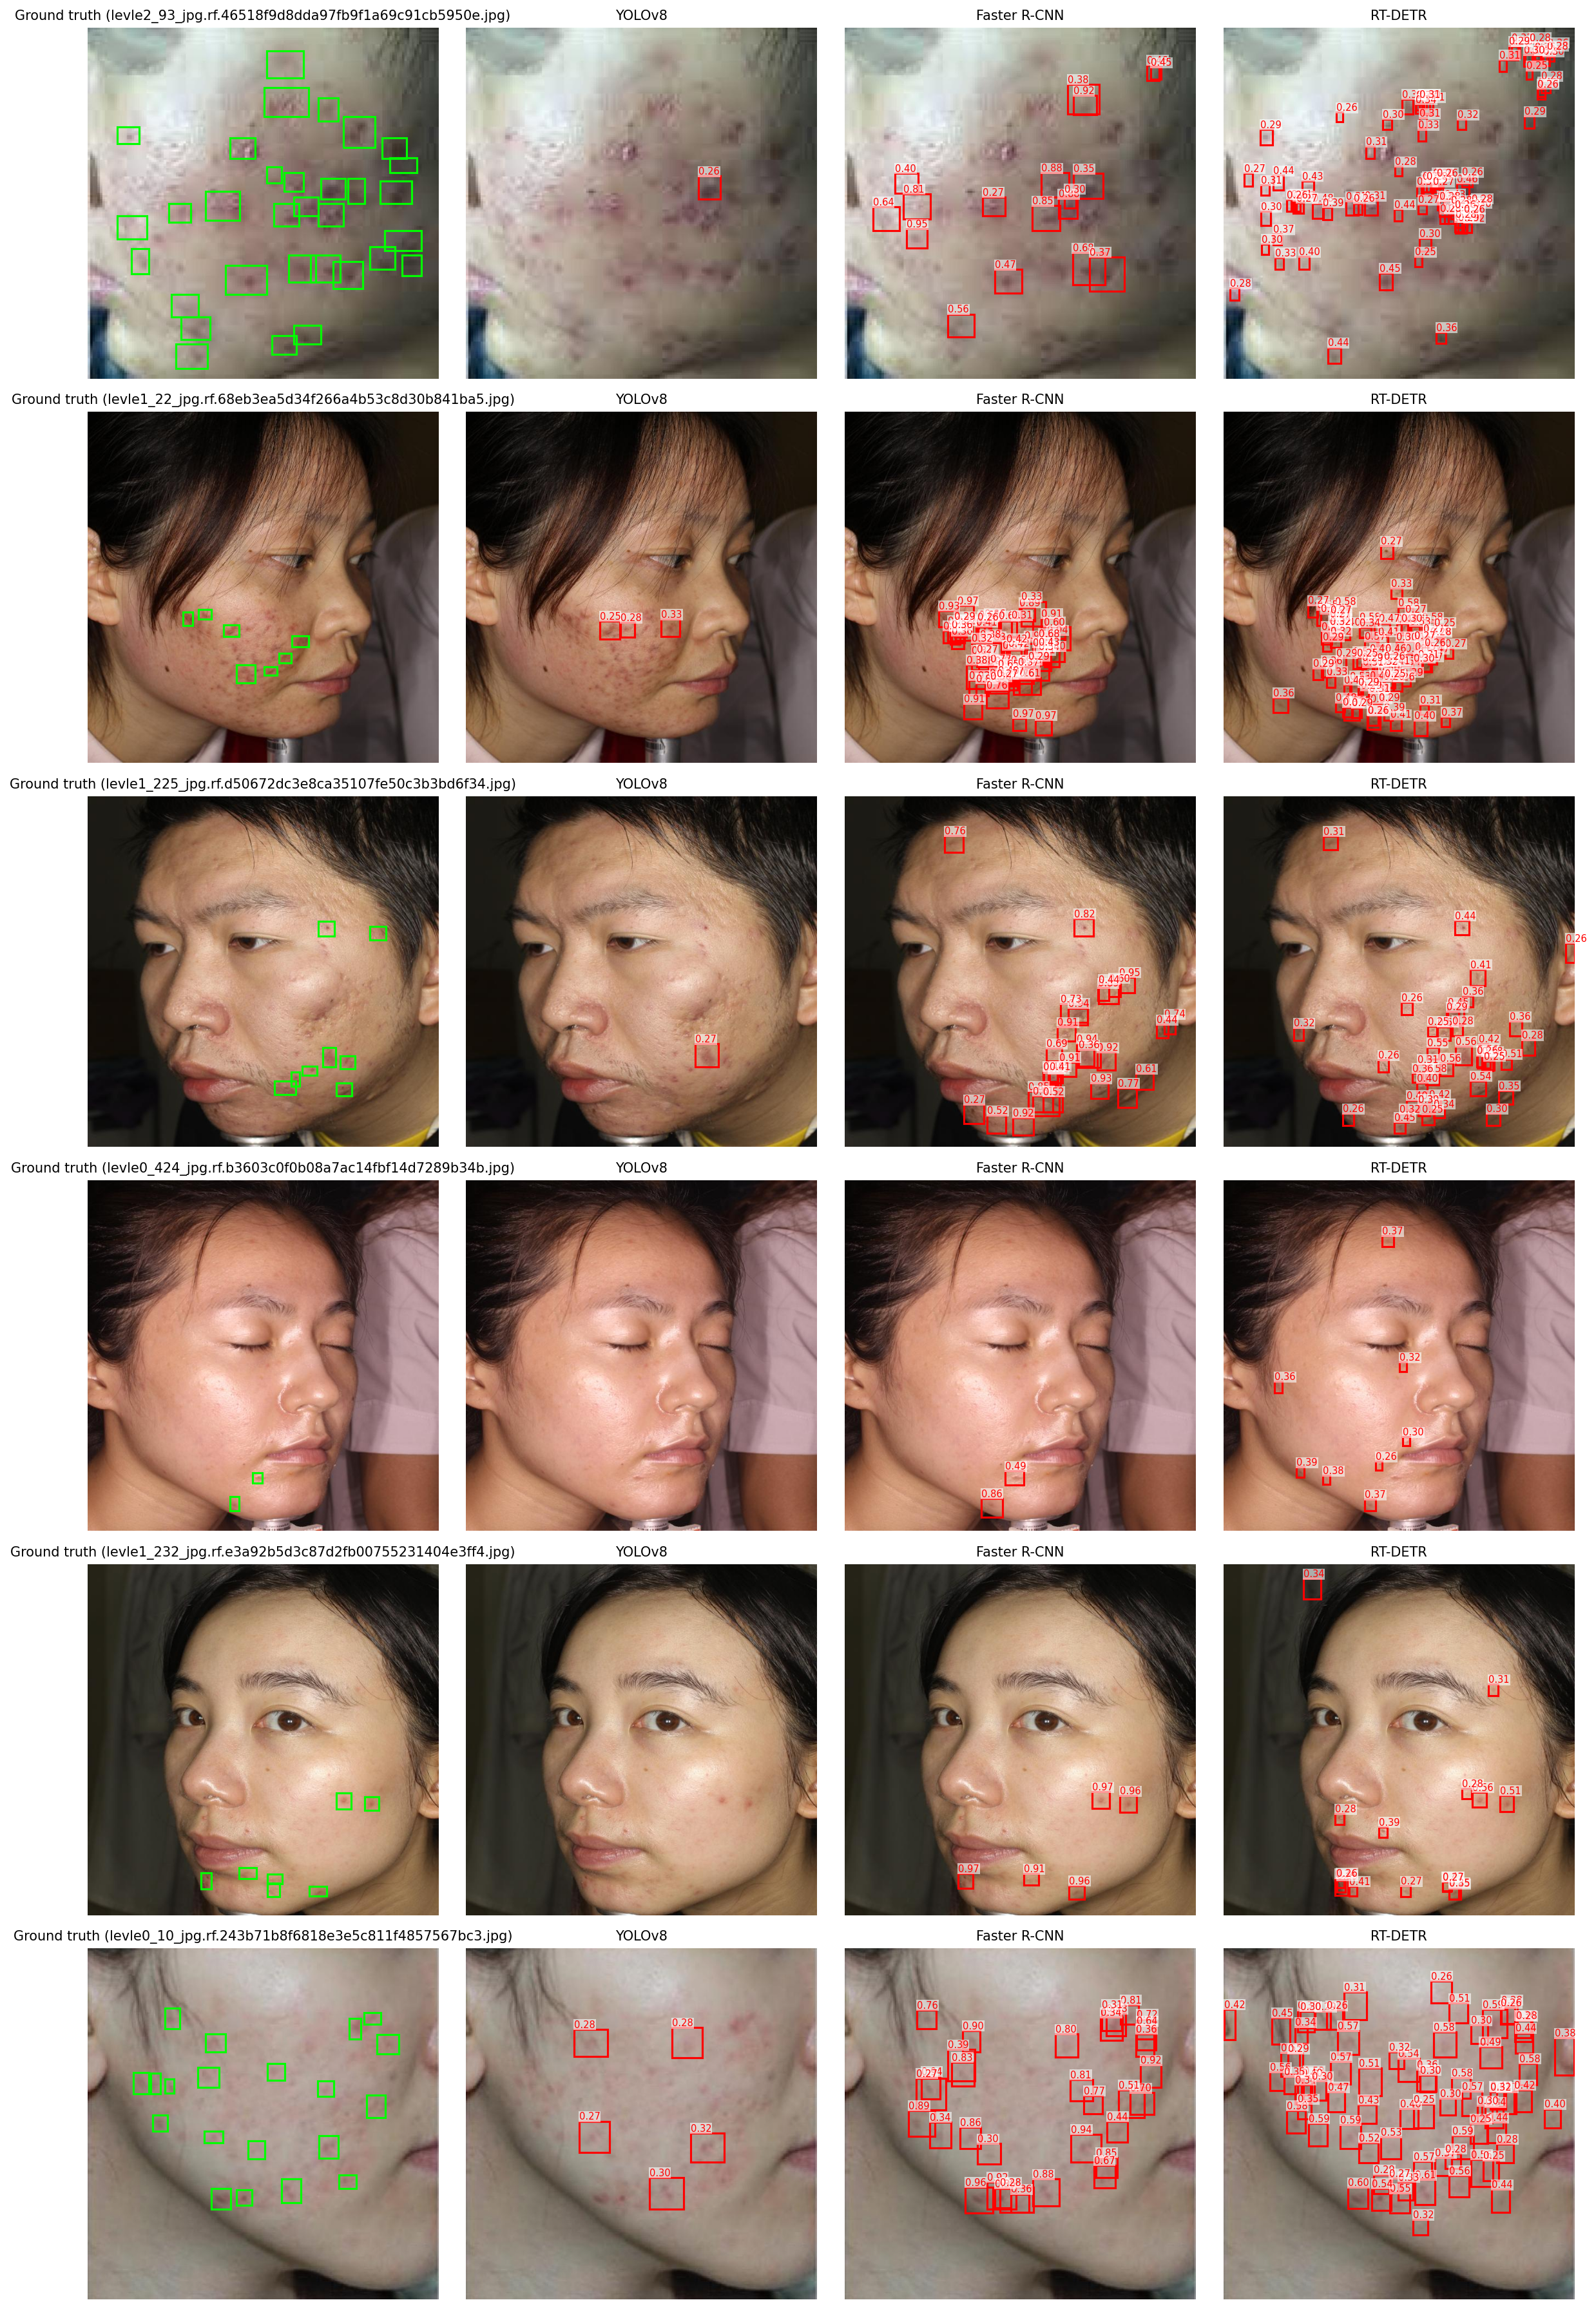

In [8]:
from part1_detection.visualize import visualize_predictions
from IPython.display import Image as IPyImage

out = visualize_predictions(
    models={
        'YOLOv8':       {'kind': 'yolo',   'weights': '/content/acne_yang_project/runs/detect/outputs/yolov8/acne/weights/best.pt'},
        'Faster R-CNN': {'kind': 'frcnn',  'weights': 'outputs/faster_rcnn/best.pth'},
        'RT-DETR':      {'kind': 'rtdetr', 'weights': '/content/acne_yang_project/runs/detect/outputs/rtdetr/acne/weights/best.pt'},
    },
    coco_root=str(coco_root),
    n_images=6,
)
IPyImage(filename=str(out))

In [9]:
# === Save all training artifacts to Google Drive ===
import os, shutil, datetime
DRIVE_ROOT = '/content/drive/MyDrive/acne_yang_project_runs'

# (optional) keep a timestamped snapshot so you don't overwrite earlier runs
SNAPSHOT = os.path.join(DRIVE_ROOT, datetime.datetime.now().strftime('snap_%Y%m%d_%H%M'))
os.makedirs(SNAPSHOT, exist_ok=True)

for src in ['outputs', 'runs']:
    if os.path.isdir(src):
        dst_latest   = os.path.join(DRIVE_ROOT, src)          # always-current copy
        dst_snapshot = os.path.join(SNAPSHOT,   src)          # frozen copy
        print(f'[save] {src}/ -> {dst_latest}/ (+ snapshot)')
        shutil.copytree(src, dst_latest,   dirs_exist_ok=True)
        shutil.copytree(src, dst_snapshot, dirs_exist_ok=True)
    else:
        print(f'[skip] {src}/ does not exist')

print('\n[save] done. Drive contents:')
!ls -lh "$DRIVE_ROOT"
print('\n[save] snapshot saved at:', SNAPSHOT)


[save] outputs/ -> /content/drive/MyDrive/acne_yang_project_runs/outputs/ (+ snapshot)
[save] runs/ -> /content/drive/MyDrive/acne_yang_project_runs/runs/ (+ snapshot)

[save] done. Drive contents:
total 20K
drwx------ 5 root root 4.0K May 13 03:06 outputs
drwx------ 3 root root 4.0K May 13 00:42 runs
drwx------ 2 root root 4.0K May 12 01:04 snap_20260512_0104
drwx------ 2 root root 4.0K May 12 09:28 snap_20260512_0928
drwx------ 4 root root 4.0K May 13 03:07 snap_20260513_0306

[save] snapshot saved at: /content/drive/MyDrive/acne_yang_project_runs/snap_20260513_0306
